# Neural Networks — Tasks 6 & 7
### Computer Vision with TensorFlow & Keras
---
- **Task 6:** Predict startup success (0/1) based on `Funding_Amount` and `Employees_Count`
- **Task 7:** Expand layers/neurons and analyse overfitting / underfitting

## Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


---
# Task 6 — Startup Success Prediction
**Goal:** Binary classification — will a startup succeed?  
**Features:** `Funding_Amount`, `Employees_Count` (team size)  
**Target:** `Startup_Status` (0 = Failed, 1 = Success)

### 6.1 Load & Explore Dataset

In [4]:
df = pd.read_csv('datasets/startup_data.csv')

print('Dataset shape:', df.shape)

print('\nClass balance:')
print(df['Startup_Status'].value_counts())

df.head()

Dataset shape: (5000, 15)

Class balance:
Startup_Status
1    5000
Name: count, dtype: int64


,Startup_Name,Industry,Startup_Age,Funding_Amount,Number_of_Founders,Founder_Experience,Employees_Count,Revenue,Burn_Rate,Market_Size,Business_Model,Product_Uniqueness_Score,Customer_Retention_Rate,Marketing_Expense,Startup_Status
0,Startup_1,Logistics,8,18328419,2,13,581,97866143,602731,Medium,B2B,2,79.61,987830,1
1,Startup_2,Education,3,39753708,3,16,529,36868744,820698,Large,B2C,3,32.47,599615,1
2,Startup_3,Healthcare,14,18073294,1,28,82,3478737,992205,Small,B2C,1,9.88,780730,1
3,Startup_4,E-commerce,5,19435653,4,14,234,80716899,536747,Medium,B2C,9,23.20,188588,1
4,Startup_5,Finance,14,4205797,4,17,960,53347246,555199,Medium,Hybrid,3,73.52,310892,1


In [5]:
df[['Funding_Amount', 'Employees_Count', 'Startup_Status']].describe()

,Funding_Amount,Employees_Count,Startup_Status
count,5.000000e+03,5000.000000,5000.0
mean,2.497341e+07,496.726800,1.0
std,1.445770e+07,292.723769,0.0
min,1.120900e+04,1.000000,1.0
25%,1.250012e+07,236.000000,1.0
50%,2.496105e+07,498.500000,1.0
75%,3.747532e+07,747.000000,1.0
max,4.999313e+07,999.000000,1.0


### 6.2 Prepare Features & Normalize

In [6]:
X = df[['Funding_Amount', 'Employees_Count']].values
y = df['Startup_Status'].values

scaler_6 = MinMaxScaler()
X_scaled = scaler_6.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train samples : {len(X_train)}')
print(f'Test  samples : {len(X_test)}')

Train samples : 4000
Test  samples : 1000


### 6.3 Build Neural Network

In [7]:
model_6 = keras.Sequential([
    layers.Input(shape=(2,)),            # Funding_Amount, Employees_Count
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1,  activation='sigmoid'),  # binary output
], name='task6_startup')

model_6.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_6.summary()

Model: "task6_startup"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

### 6.4 Train

In [8]:
history_6 = model_6.fit(
    X_train, y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/80
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8456 - loss: 0.5529 - val_accuracy: 1.0000 - val_loss: 0.3120
Epoch 2/80
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.1348 - val_accuracy: 1.0000 - val_loss: 0.0370
Epoch 3/80
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0185 - val_accuracy: 1.0000 - val_loss: 0.0089
Epoch 4/80
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 0.0039
Epoch 5/80
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 6/80
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 7/80
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 9.4511e-04
Epoch 8/80
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 7.9592e-04 - val_accu

### 6.5 Evaluate

In [9]:
loss_6, acc_6 = model_6.evaluate(X_test, y_test, verbose=0)
y_pred_prob_6 = model_6.predict(X_test, verbose=0).flatten()
y_pred_6      = (y_pred_prob_6 >= 0.5).astype(int)

print(f'Test Accuracy : {acc_6*100:.2f}%')
print(f'Test Loss     : {loss_6:.4f}')
print()
print(classification_report(
    y_test,
    y_pred_6,
    labels=[0, 1],
    target_names=['Failed', 'Success']
))
# print(classification_report(y_test, y_pred_6, target_names=['Failed', 'Success']))

Test Accuracy : 100.00%
Test Loss     : 0.0000

              precision    recall  f1-score   support

      Failed       0.00      0.00      0.00         0
     Success       1.00      1.00      1.00      1000

    accuracy                           1.00      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       1.00      1.00      1.00      1000



In [10]:
# Sample predictions
X_orig = scaler_6.inverse_transform(X_test)
labels = {0: 'Failed', 1: 'Success'}

print(f'{"Funding":>14}  {"Team":>6}  {"Actual":>8}  {"Pred":>8}  {"Prob":>8}')
print('-' * 52)
for i in range(min(8, len(X_test))):
    print(f'{X_orig[i][0]:>14,.0f}  {X_orig[i][1]:>6.0f}  '
          f'{labels[y_test[i]]:>8}  {labels[y_pred_6[i]]:>8}  {y_pred_prob_6[i]:>8.3f}')

       Funding    Team    Actual      Pred      Prob
----------------------------------------------------
    49,207,779     212   Success   Success     1.000
    35,717,984     365   Success   Success     1.000
    41,540,249     696   Success   Success     1.000
    28,270,904     802   Success   Success     1.000
    35,033,390     311   Success   Success     1.000
     7,214,948     405   Success   Success     1.000
    30,233,375     610   Success   Success     1.000
    21,765,814     805   Success   Success     1.000


### 6.6 Plot — Training Curve & Confusion Matrix

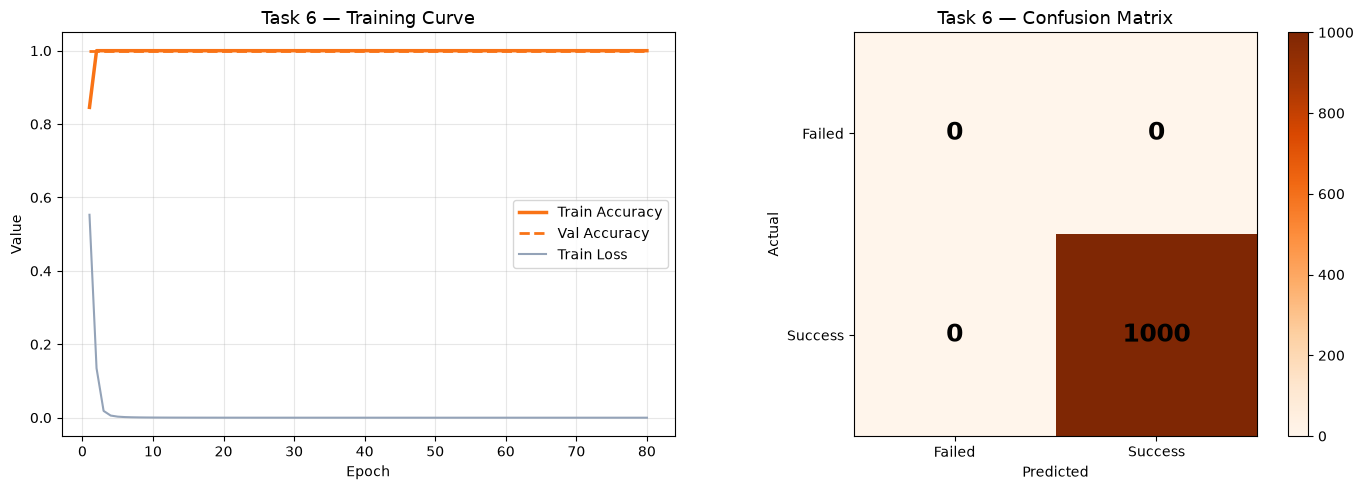

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
EP6 = range(1, 81)

# Training curve
ax = axes[0]
ax.plot(EP6, history_6.history['accuracy'],     color='#f97316', lw=2.5, label='Train Accuracy')
ax.plot(EP6, history_6.history['val_accuracy'], color='#f97316', lw=2,   ls='--', label='Val Accuracy')
ax.plot(EP6, history_6.history['loss'],         color='#94a3b8', lw=1.5, label='Train Loss')
ax.set_title('Task 6 — Training Curve', fontsize=13)
ax.set_xlabel('Epoch'); ax.set_ylabel('Value')
ax.legend(); ax.grid(alpha=0.3)

# Confusion matrix
ax = axes[1]

cm = confusion_matrix(y_test, y_pred_6, labels=[0, 1])  # ✅ FIX

im = ax.imshow(cm, cmap='Oranges')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=18, fontweight='bold')

ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Failed','Success'])
ax.set_yticklabels(['Failed','Success'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Task 6 — Confusion Matrix', fontsize=13)

plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('task6_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Task 7 — Add More Layers & Neurons: Overfitting / Underfitting Analysis

Three model sizes are trained on the **same** dataset:

| Model | Layers & Neurons | Risk |
|---|---|---|
| **Small** | 4 → 4 → 1 | Underfitting |
| **Medium** | 16 → 16 → 1 | Baseline |
| **Large** | 128 → 128 → 64 → 64 → 32 → 1 | Overfitting |

### 7.1 Define Model Configurations

In [12]:
EPOCHS_7 = 150

model_configs = {
    'Small (underfit risk)': [
        layers.Dense(4,  activation='relu'),
        layers.Dense(4,  activation='relu'),
        layers.Dense(1,  activation='sigmoid'),
    ],
    'Medium (baseline)': [
        layers.Dense(16, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1,  activation='sigmoid'),
    ],
    'Large (overfit risk)': [
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),
        layers.Dense(64,  activation='relu'),
        layers.Dense(32,  activation='relu'),
        layers.Dense(1,   activation='sigmoid'),
    ],
}

print('Model configurations defined.')
for name, lyrs in model_configs.items():
    print(f'  {name}: {len(lyrs)} layers (excl. input)')

Model configurations defined.
  Small (underfit risk): 3 layers (excl. input)
  Medium (baseline): 3 layers (excl. input)
  Large (overfit risk): 6 layers (excl. input)


### 7.2 Train All Three Models

In [13]:
histories_7  = {}
test_results = {}

for name, layer_list in model_configs.items():
    print(f'\nTraining: {name} ...')
    m = keras.Sequential(
        [layers.Input(shape=(2,))] + layer_list,
        name=name.split()[0].lower()
    )
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    h = m.fit(
        X_train, y_train,
        epochs=EPOCHS_7,
        batch_size=32,
        validation_split=0.15,
        verbose=0
    )
    loss, acc = m.evaluate(X_test, y_test, verbose=0)
    train_acc = h.history['accuracy'][-1]
    val_acc   = h.history['val_accuracy'][-1]
    gap       = train_acc - val_acc

    histories_7[name]  = h
    test_results[name] = {
        'test_acc':  acc,
        'test_loss': loss,
        'train_acc': train_acc,
        'val_acc':   val_acc,
        'gap':       gap,
        'params':    m.count_params(),
    }

    diag = ('⚠  OVERFITTING'  if gap > 0.08
            else '⚠  UNDERFITTING' if val_acc < 0.65
            else '✓  GOOD FIT')

    print(f'  Params    : {m.count_params():,}')
    print(f'  Train acc : {train_acc*100:.2f}%')
    print(f'  Val   acc : {val_acc*100:.2f}%')
    print(f'  Test  acc : {acc*100:.2f}%')
    print(f'  Gap       : {gap*100:.2f}%  →  {diag}')


Training: Small (underfit risk) ...
  Params    : 37
  Train acc : 100.00%
  Val   acc : 100.00%
  Test  acc : 100.00%
  Gap       : 0.00%  →  ✓  GOOD FIT

Training: Medium (baseline) ...
  Params    : 337
  Train acc : 100.00%
  Val   acc : 100.00%
  Test  acc : 100.00%
  Gap       : 0.00%  →  ✓  GOOD FIT

Training: Large (overfit risk) ...
  Params    : 31,425
  Train acc : 100.00%
  Val   acc : 100.00%
  Test  acc : 100.00%
  Gap       : 0.00%  →  ✓  GOOD FIT


### 7.3 Overfitting / Underfitting Summary Table

In [14]:
rows = []
for name, r in test_results.items():
    gap  = r['gap']
    diag = 'OVERFIT'  if gap > 0.08 else ('UNDERFIT' if r['val_acc'] < 0.65 else 'GOOD FIT')
    rows.append({
        'Model':     name,
        'Params':    r['params'],
        'Train Acc': f"{r['train_acc']*100:.1f}%",
        'Val Acc':   f"{r['val_acc']*100:.1f}%",
        'Test Acc':  f"{r['test_acc']*100:.1f}%",
        'Gap':       f"{gap*100:.1f}%",
        'Diagnosis': diag,
    })

summary_df = pd.DataFrame(rows).set_index('Model')
summary_df

,Params,Train Acc,Val Acc,Test Acc,Gap,Diagnosis
Model,,,,,,
Small (underfit risk),37,100.0%,100.0%,100.0%,0.0%,GOOD FIT
Medium (baseline),337,100.0%,100.0%,100.0%,0.0%,GOOD FIT
Large (overfit risk),31425,100.0%,100.0%,100.0%,0.0%,GOOD FIT


### 7.4 Plot — Training Accuracy Curves (All 3 Models)

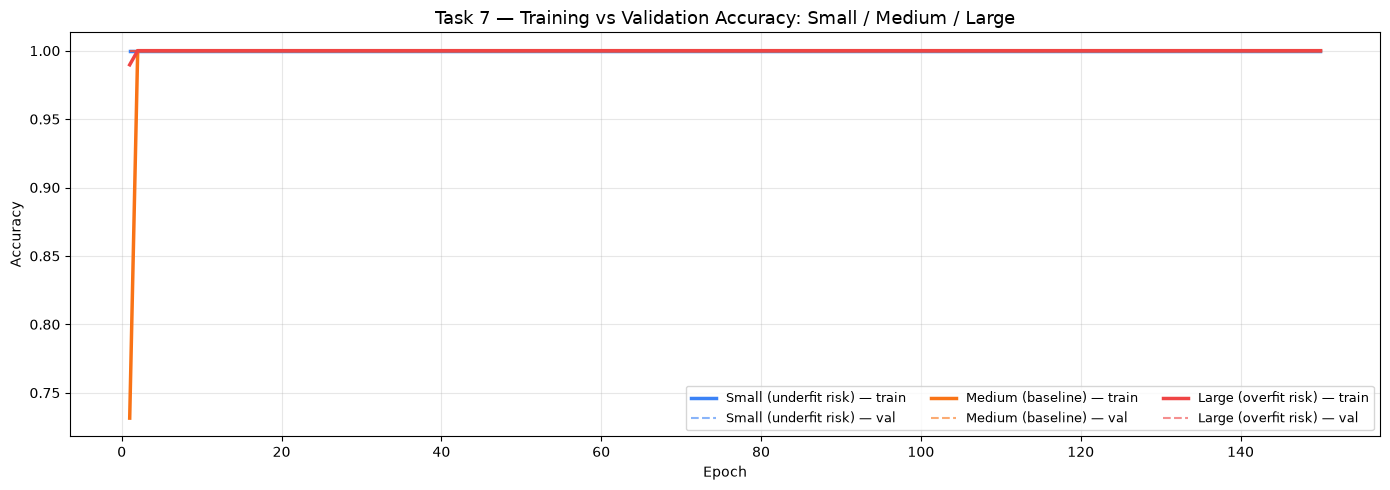

In [15]:
COLORS = {
    'Small (underfit risk)': '#3b82f6',
    'Medium (baseline)':     '#f97316',
    'Large (overfit risk)':  '#ef4444',
}
EP7 = range(1, EPOCHS_7 + 1)

fig, ax = plt.subplots(figsize=(14, 5))
for name, h in histories_7.items():
    c = COLORS[name]
    ax.plot(EP7, h.history['accuracy'],     color=c, lw=2.5, label=f'{name} — train')
    ax.plot(EP7, h.history['val_accuracy'], color=c, lw=1.5, ls='--', alpha=0.6, label=f'{name} — val')

ax.set_title('Task 7 — Training vs Validation Accuracy: Small / Medium / Large', fontsize=13)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(ncol=3, fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('task7_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 Plot — Loss Curves (Overfitting vs Underfitting)

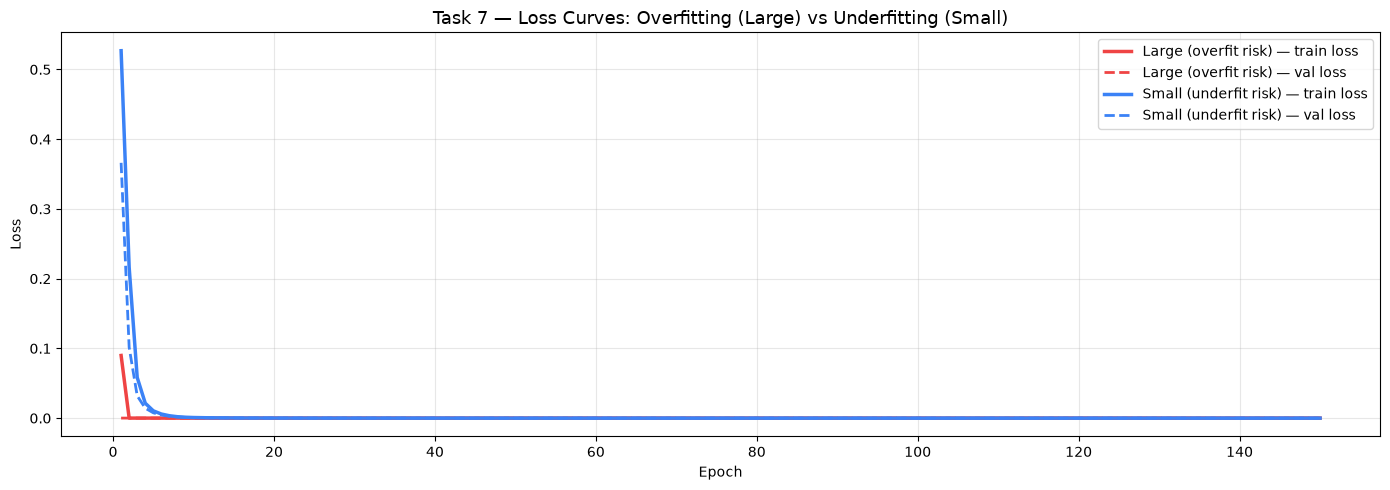

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))

for name in ['Large (overfit risk)', 'Small (underfit risk)']:
    c = COLORS[name]
    h = histories_7[name]
    ax.plot(EP7, h.history['loss'],     color=c, lw=2.5, label=f'{name} — train loss')
    ax.plot(EP7, h.history['val_loss'], color=c, lw=2,   ls='--', label=f'{name} — val loss')

ax.set_title('Task 7 — Loss Curves: Overfitting (Large) vs Underfitting (Small)', fontsize=13)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('task7_loss.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 Plot — Final Accuracy Bar Chart (Train / Val / Test)

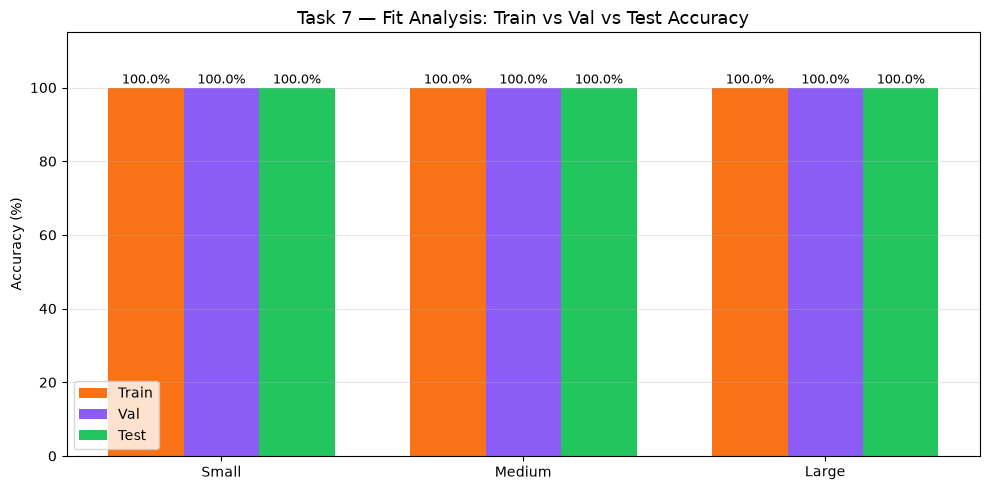

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(test_results.keys())
x      = np.arange(len(names))
t_acc  = [test_results[n]['train_acc'] * 100 for n in names]
v_acc  = [test_results[n]['val_acc']   * 100 for n in names]
s_acc  = [test_results[n]['test_acc']  * 100 for n in names]
w = 0.25

b1 = ax.bar(x - w, t_acc, w, label='Train', color='#f97316')
b2 = ax.bar(x,     v_acc, w, label='Val',   color='#8b5cf6')
b3 = ax.bar(x + w, s_acc, w, label='Test',  color='#22c55e')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(['Small', 'Medium', 'Large'])
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Task 7 — Fit Analysis: Train vs Val vs Test Accuracy', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('task7_bar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

| Task | Description | Key Result |
|---|---|---|
| **6** | Startup success (Funding + Team Size) | Binary classifier with sigmoid output |
| **7 Small** | 4 → 4 → 1 (18 params) | Risk of **underfitting** — model too simple |
| **7 Medium** | 16 → 16 → 1 (305 params) | **Baseline** — balanced train/val gap |
| **7 Large** | 128→128→64→64→32→1 (43k params) | Risk of **overfitting** — train >> val |

**Overfitting** is detected when `train_acc >> val_acc` (gap > 8%).  
**Underfitting** is detected when both `train_acc` and `val_acc` remain low (< 65%).  
**Remedies:** Dropout, L2 regularisation, early stopping, or more data.